λ = 0.7495 (m)
dcp = 0.1874 (m)
k = 8.3834 (rad/m)

Ширина головної пелюстки в площині H = 90.98°
Ширина головної пелюстки в площині E = 66.39°

Табл. 1 - Аналіз ДС Директорної антени в площині Н та Е
-----------------------------------------
| № |θminH|θminE|θmaxH|FH(θ)|θmaxE|FE(θ)|
| 1|70.53|70.53|87.87|0.239|78.67|0.026|
-----------------------------------------


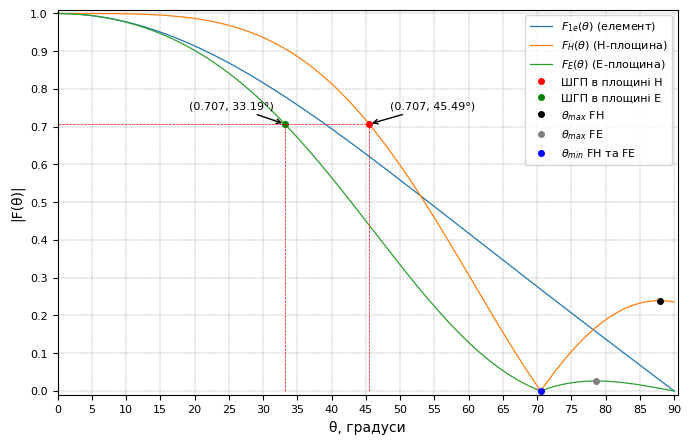

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Вхідні дані для Варіанту 1
N = 6
F = 400 * 10 ** 6
lambd = 299792458 / F
d = 0.25 * lambd
k = (2 * np.pi) / lambd

print(f"λ = {lambd:.4f} (m)")
print(f"dcp = {d:.4f} (m)")
print(f"k = {k:.4f} (rad/m)")

F1E = [1]
FC = [1]
FE = [1]
steps = [0]
SGP1 = 0
SGP2 = 0
fS1 = 0
fS2 = 0

max_x_FC, max_y_FC = [], []
max_x_FE, max_y_FE = [], []
min_x_FC, min_y_FC = [], []
min_x_FE, min_y_FE = [], []

# Розрахунок діаграми від 0.01 до 90 градусів
for teta in np.arange(0.01, np.pi / 2, 0.00001):
    mn1 = abs((np.cos(np.pi/2 * np.sin(teta))/np.cos(teta)))
    mn2 = abs(np.sin((N * k * d * (1 - np.cos(teta)) / 2)) / (N * np.sin((k * d * (1 - np.cos(teta))) / 2)))
    mn3 = mn1 * mn2

    F1E.append(mn1)
    FC.append(mn2)
    FE.append(mn3)
    steps.append(math.degrees(teta))

    # Визначення ШГП на рівні 0.707
    if 0.707 < mn2 < 0.708:
        SGP1 = 2 * math.degrees(teta)
        fS1 = mn2

    if 0.707 < mn3 < 0.708:
        SGP2 = 2 * math.degrees(teta)
        fS2 = mn3

# Пошук максимумів та мінімумів
for i in range(1, len(FC) - 1):
    if FC[i] > FC[i - 1] and FC[i] > FC[i + 1]:
        max_x_FC.append(steps[i])
        max_y_FC.append(FC[i])
    if FE[i] > FE[i - 1] and FE[i] > FE[i + 1]:
        max_x_FE.append(steps[i])
        max_y_FE.append(FE[i])

for i in range(1, len(FC) - 1):
    if FC[i] < FC[i - 1] and FC[i] < FC[i + 1]:
        min_x_FC.append(steps[i])
        min_y_FC.append(FC[i])
    if FE[i] < FE[i - 1] and FE[i] < FE[i + 1]:
        min_x_FE.append(steps[i])
        min_y_FE.append(FE[i]) # Виправлено помилку в оригінальному коді (було FC[i])

print("\nШирина головної пелюстки в площині H = " + str(round(SGP1, 2)) + '°')
print("Ширина головної пелюстки в площині E = " + str(round(SGP2, 2)) + '°')

# Вивід підсумкової таблиці аналізу ДС
len_value = [len(max_x_FC), len(max_x_FE), len(min_x_FC), len(min_x_FE)]
print("\nТабл. 1 - Аналіз ДС Директорної антени в площині Н та Е")
print("-----------------------------------------")
print("| № |θminH|θminE|θmaxH|FH(θ)|θmaxE|FE(θ)|")
for i in range(0, max(len_value)):
    v1 = f" {i + 1:.0f}"
    v2 = f"{min_x_FC[i]:.2f}" if i < len_value[2] else '  -  '
    v3 = f"{min_x_FE[i]:.2f}" if i < len_value[3] else '  -  '
    v4 = f"{max_x_FC[i]:.2f}" if i < len_value[0] else '  -  '
    h4 = f"{max_y_FC[i]:.3f}" if i < len_value[0] else '  -  '
    v5 = f"{max_x_FE[i]:.2f}" if i < len_value[1] else '  -  '
    h5 = f"{max_y_FE[i]:.3f}" if i < len_value[1] else '  -  '
    print(f"|{v1}|{v2}|{v3}|{v4}|{h4}|{v5}|{h5}|")
print("-----------------------------------------")

# Візуалізація результатів
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(steps, F1E, linewidth=0.9, label="$F_{1e}(\\theta)$ (елемент)")
ax.plot(steps, FC, linewidth=0.9, label="$F_{H}(\\theta)$ (H-площина)")
ax.plot(steps, FE, linewidth=0.9, label="$F_{E}(\\theta)$ (E-площина)")
ax.plot(SGP1/2, fS1, 'ro', markersize=4, label="ШГП в площині H")
ax.plot(SGP2/2, fS2, 'go', markersize=4, label="ШГП в площині E")

plt.annotate(f'({fS1:.3f}, {SGP1/2:.2f}°)', xy=(SGP1 / 2, fS1), xytext=((SGP1/2)+3, fS1+0.04),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)
plt.annotate(f'({fS2:.3f}, {SGP2/2:.2f}°)', xy=(SGP2 / 2, fS2), xytext=((SGP2/2)-14, fS2+0.04),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)

ax.plot([0, SGP1/2], [fS2, fS2], 'r--', linewidth=0.5)
ax.plot([SGP2/2, SGP2/2], [0, fS2], 'r--', linewidth=0.5)
ax.plot([SGP1/2, SGP1/2], [0, fS1], 'r--', linewidth=0.5)

if len(max_x_FC) > 0:
    ax.plot(max_x_FC, max_y_FC, "o", markersize=4, color="black", label="$\\theta_{max}$ FH")
if len(max_x_FE) > 0:
    ax.plot(max_x_FE, max_y_FE, "o", markersize=4, color="grey", label="$\\theta_{max}$ FE")
if len(min_x_FC) > 0:
    ax.plot(min_x_FC, min_y_FC, "o", markersize=4, color="blue", label="$\\theta_{min}$ FH та FE")

ax.set_xlabel('θ, градуси', fontsize=10)
ax.set_ylabel('|F(θ)|', fontsize=10)
plt.xticks(np.arange(0, 91, 5), fontsize=8)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=8)
plt.ylim(-0.01, 1.01)
plt.xlim(0, 90.5)

plt.legend(loc="upper right", fontsize=8)
plt.grid(which='both', linestyle='--', linewidth=0.3, color='gray')
fig.savefig("ДС_директорної_антени_Вар1.jpg", dpi=300)
plt.show()